<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/ZomatoDeliveryTimePrediction/blob/main/notebooks/01DataPreparation_zd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Delivery Time Prediction — 01: Data Preparation

Covers: Kaggle download, dataset audit, EDA, geographic/temporal feature engineering,
leakage audit, train/val/test split. Output: cleaned, feature-engineered dataset saved to Drive.

In [1]:
!kaggle datasets download -d saurabhbadole/zomato-delivery-operations-analytics-dataset -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/saurabhbadole/zomato-delivery-operations-analytics-dataset
License(s): other
100% 1.43M/1.43M [00:00<00:00, 2.60MB/s]



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

RAW_DATA_DIR = "data/raw"
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/zomato-delivery-time-prediction"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Load Data

In [4]:
df = pd.read_csv(f"{RAW_DATA_DIR}/Zomato Dataset.csv")
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


## Initial Structural Inspection

Shape, column names, dtypes — before assuming anything about the schema.

In [5]:
print(f"Shape: {df.shape}")
df.info()

Shape: (45584, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 1

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
Delivery_person_Ratings,1908,4.19
Delivery_person_Age,1854,4.07
Time_Orderd,1731,3.80
City,1200,2.63
multiple_deliveries,993,2.18
Weather_conditions,616,1.35
Road_traffic_density,601,1.32
Festival,228,0.50


In [7]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")

Exact duplicate rows: 0


In [8]:
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols].nunique().sort_values(ascending=False)

,0
ID,45584
Delivery_person_ID,1320
Time_Order_picked,193
Time_Orderd,176
Order_Date,44
Weather_conditions,6
Road_traffic_density,4
Type_of_order,4
Type_of_vehicle,4
City,3


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,43730.0,29.566911,5.815064,15.000000,25.000000,30.000000,35.000000,50.000000
Delivery_person_Ratings,43676.0,4.633774,0.334744,1.000000,4.500000,4.700000,4.900000,6.000000
Restaurant_latitude,45584.0,17.017948,8.185674,-30.905562,12.933284,18.551440,22.728163,30.914057
Restaurant_longitude,45584.0,70.229684,22.885575,-88.366217,73.170000,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,17.465480,7.335562,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,70.844161,21.120578,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45584.0,1.023385,0.839055,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44591.0,0.744635,0.572510,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken (min),45584.0,26.293963,9.384298,10.000000,19.000000,26.000000,32.000000,54.000000


## Column-Level Inspection

Check actual unique values per categorical column, and sanity-check coordinates, timestamps,
and the target distribution.

In [10]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- ID ---
['0xcdcd' '0xd987' '0x2784' ... '0x4f8d' '0x5eee' '0x5fb2']

--- Delivery_person_ID ---
['DEHRES17DEL01' 'KOCRES16DEL01' 'PUNERES13DEL03' ... 'KOCRES04DEL01'
 'BHPRES06DEL03' 'GOARES03DEL03']

--- Order_Date ---
['12-02-2022' '13-02-2022' '04-03-2022' '14-02-2022' '02-04-2022'
 '01-03-2022' '16-03-2022' '20-03-2022' '15-02-2022' '10-03-2022'
 '11-03-2022' '27-03-2022' '26-03-2022' '05-04-2022' '12-03-2022'
 '01-04-2022' '05-03-2022' '11-02-2022' '08-03-2022' '03-04-2022'
 '30-03-2022' '28-03-2022' '18-03-2022' '14-03-2022' '06-04-2022'
 '04-04-2022' '24-03-2022' '19-03-2022' '09-03-2022' '25-03-2022'
 '02-03-2022' '13-03-2022' '29-03-2022' '31-03-2022' '17-03-2022'
 '07-03-2022' '15-03-2022' '16-02-2022' '03-03-2022' '18-02-2022'
 '23-03-2022' '17-02-2022' '06-03-2022' '21-03-2022']

--- Time_Orderd ---
['21:55' '14:55' '17:30' '09:20' '19:50' '20:25' '20:30' '20:40' '21:15'
 '20:20' '22:30' '08:15' '19:30' '12:25' '18:35' '20:35' '23:20' '21:20'
 '23:35' '22:35' '23:25' '13

In [11]:
coord_cols = ["Restaurant_latitude", "Restaurant_longitude",
              "Delivery_location_latitude", "Delivery_location_longitude"]
df[coord_cols].describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
count,45584.000000,45584.000000,45584.000000,45584.000000
mean,17.017948,70.229684,17.465480,70.844161
std,8.185674,22.885575,7.335562,21.120578
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.551440,75.897963,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [12]:
suspicious_coords = df[
    (df["Restaurant_latitude"] <= 0) | (df["Restaurant_longitude"] <= 0)
]
print(f"Rows with non-positive restaurant coordinates: {len(suspicious_coords)}")
suspicious_coords[coord_cols].head(10)

Rows with non-positive restaurant coordinates: 4071


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
24,0.0,0.0,0.11,0.11
43,0.0,0.0,0.03,0.03
48,0.0,0.0,0.08,0.08
50,0.0,0.0,0.06,0.06
58,0.0,0.0,0.02,0.02
59,0.0,0.0,0.04,0.04
63,0.0,0.0,0.08,0.08
64,0.0,0.0,0.02,0.02
67,0.0,0.0,0.05,0.05
72,0.0,0.0,0.11,0.11


In [13]:
print(df["Order_Date"].head())
print(f"\nTime_Orderd missing/blank: {(df['Time_Orderd'].isna() | (df['Time_Orderd'].astype(str).str.strip() == '')).sum()}")
print(f"Time_Order_picked missing/blank: {(df['Time_Order_picked'].isna() | (df['Time_Order_picked'].astype(str).str.strip() == '')).sum()}")

0    12-02-2022
1    13-02-2022
2    04-03-2022
3    13-02-2022
4    14-02-2022
Name: Order_Date, dtype: object

Time_Orderd missing/blank: 1731
Time_Order_picked missing/blank: 0


count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64


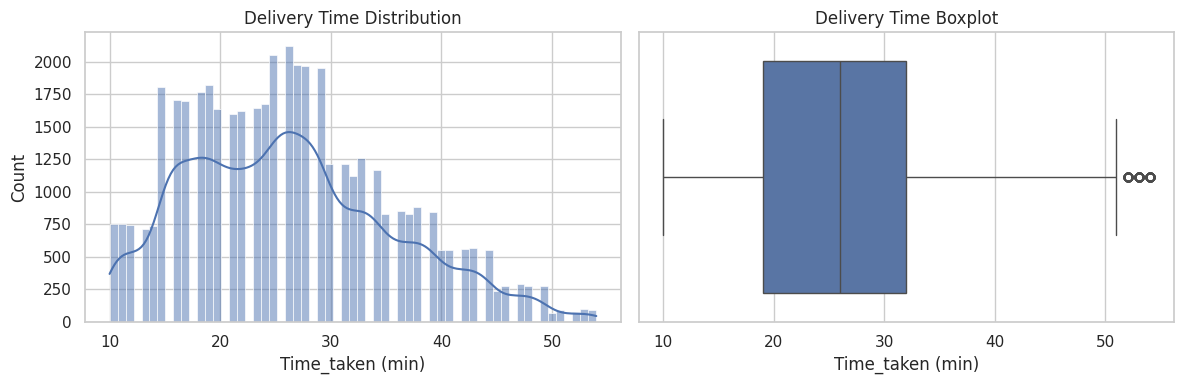


Skewness: 0.486


In [14]:
target_col = "Time_taken (min)"
print(df[target_col].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Delivery Time Distribution")
sns.boxplot(x=df[target_col], ax=axes[1])
axes[1].set_title("Delivery Time Boxplot")
plt.tight_layout()
plt.show()

print(f"\nSkewness: {df[target_col].skew():.3f}")

In [15]:
df["Time_Orderd_missing"] = df["Time_Orderd"].isna()
df.groupby("Type_of_order")["Time_Orderd_missing"].mean().sort_values(ascending=False)

,Time_Orderd_missing
Type_of_order,
Meal,0.038408
Snack,0.038335
Buffet,0.037599
Drinks,0.037541


## Data Quality: Coordinates

In [16]:
zero_coords = df[(df["Restaurant_latitude"] == 0) & (df["Restaurant_longitude"] == 0)]
negative_coords = df[
    ((df["Restaurant_latitude"] < 0) | (df["Restaurant_longitude"] < 0))
    & ~((df["Restaurant_latitude"] == 0) & (df["Restaurant_longitude"] == 0))
]

print(f"Rows with restaurant coords exactly (0, 0): {len(zero_coords)}")
print(f"Rows with negative (but not zero) restaurant coords: {len(negative_coords)}")

print("\nDelivery coord range for the zero-restaurant-coord rows:")
print(zero_coords[["Delivery_location_latitude", "Delivery_location_longitude"]].describe())

print("\nSample of negative (non-zero) rows, if any:")
negative_coords[coord_cols].head(10)

Rows with restaurant coords exactly (0, 0): 3640
Rows with negative (but not zero) restaurant coords: 431

Delivery coord range for the zero-restaurant-coord rows:
       Delivery_location_latitude  Delivery_location_longitude
count                 3640.000000                  3640.000000
mean                     0.063016                     0.063016
std                      0.036047                     0.036047
min                      0.010000                     0.010000
25%                      0.030000                     0.030000
50%                      0.060000                     0.060000
75%                      0.090000                     0.090000
max                      0.130000                     0.130000

Sample of negative (non-zero) rows, if any:


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
83,-27.163303,78.057044,27.233303,78.127044
274,-27.165108,78.015053,27.225108,78.075053
280,-18.551440,-73.804855,18.611440,73.864855
416,-30.366322,-78.070453,30.496322,78.200453
525,-12.325461,-76.632278,12.385461,76.692278
574,-12.316967,76.603067,12.326967,76.613067
753,-23.359194,-85.325447,23.449194,85.415447
1050,-26.477750,-80.351569,26.487750,80.361569
1082,-15.546594,73.760431,15.606594,73.820431
1148,-12.337978,76.616792,12.387978,76.666792


In [17]:
zero_coords_check = zero_coords.copy()
zero_coords_check["lat_delta"] = zero_coords_check["Delivery_location_latitude"] - zero_coords_check["Restaurant_latitude"]
zero_coords_check["lon_delta"] = zero_coords_check["Delivery_location_longitude"] - zero_coords_check["Restaurant_longitude"]
zero_coords_check[["lat_delta", "lon_delta"]].describe()

,lat_delta,lon_delta
count,3640.000000,3640.000000
mean,0.063016,0.063016
std,0.036047,0.036047
min,0.010000,0.010000
25%,0.030000,0.030000
50%,0.060000,0.060000
75%,0.090000,0.090000
max,0.130000,0.130000


## Data Quality: Order / Pickup Time Parsing

Three formats are mixed in `Time_Orderd` and `Time_Order_picked`: normal `HH:MM`, Excel
day-fraction serials stored as strings, and (for pickup only) `HH:MM:SS` with hour >= 24
indicating next-day rollover. Writing one parser to normalize both columns to
"minutes since midnight of Order_Date".

In [18]:
import re

def parse_order_time(value):
    """
    Parse messy order/pickup time values into minutes since midnight (float).
    Handles:
      - 'HH:MM'                -> direct
      - 'HH:MM:SS' (H can be >=24, meaning next-day rollover) -> direct, keeps >1440
      - Excel day-fraction serials as strings, e.g. '0.458333333', or bare '1' -> frac * 24 * 60
    Returns np.nan if missing or unparseable.
    """
    if pd.isna(value):
        return np.nan
    s = str(value).strip()

    if re.fullmatch(r"\d*\.\d+", s) or s == "1":
        return float(s) * 24 * 60

    if re.fullmatch(r"\d{1,2}:\d{2}:\d{2}", s):
        h, m, sec = (int(x) for x in s.split(":"))
        return h * 60 + m + sec / 60

    if re.fullmatch(r"\d{1,2}:\d{2}", s):
        h, m = (int(x) for x in s.split(":"))
        return h * 60 + m

    return np.nan

# Sanity check against the actual unique values we saw
test_values = ["21:55", "0.458333333", "1", "24:05:00", np.nan]
for v in test_values:
    print(f"{v!r:20} -> {parse_order_time(v)}")

'21:55'              -> 1315
'0.458333333'        -> 659.99999952
'1'                  -> 1440.0
'24:05:00'           -> 1445.0
nan                  -> nan


In [19]:
df["order_time_min"] = df["Time_Orderd"].apply(parse_order_time)
df["pickup_time_min"] = df["Time_Order_picked"].apply(parse_order_time)

# Anything that was non-null in the original but failed to parse?
failed_order = df[df["Time_Orderd"].notna() & df["order_time_min"].isna()]
failed_pickup = df[df["Time_Order_picked"].notna() & df["pickup_time_min"].isna()]
print(f"Failed to parse - order_time: {len(failed_order)}, pickup_time: {len(failed_pickup)}")

Failed to parse - order_time: 0, pickup_time: 0


In [20]:
df["prep_time_min"] = df["pickup_time_min"] - df["order_time_min"]
print(df["prep_time_min"].describe())
print(f"\nNegative prep times (likely un-flagged midnight rollover): {(df['prep_time_min'] < 0).sum()}")

count    43853.000000
mean         9.989168
std          4.087516
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: prep_time_min, dtype: float64

Negative prep times (likely un-flagged midnight rollover): 0


## Coordinate Cleaning

In [21]:
for col in coord_cols:
    df[col] = df[col].abs()

# Re-verify: only the true (0,0) rows should remain as "suspicious" now
still_zero = df[(df["Restaurant_latitude"] == 0) & (df["Restaurant_longitude"] == 0)]
print(f"Rows still at (0,0) after abs() fix: {len(still_zero)}")  # should match the 3640 we found

Rows still at (0,0) after abs() fix: 3640


In [22]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Great-circle distance in km between two lat/lon points (vectorized, works on pandas Series).
    """
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Quick sanity check: Delhi restaurant -> Delhi delivery location, row 0
test_row = df.iloc[0]
test_dist = haversine_distance(
    test_row["Restaurant_latitude"], test_row["Restaurant_longitude"],
    test_row["Delivery_location_latitude"], test_row["Delivery_location_longitude"]
)
print(f"Sample distance: {test_dist:.2f} km")  # should be a small, plausible number

Sample distance: 10.28 km


In [23]:
df["coords_corrupted"] = (df["Restaurant_latitude"] == 0) & (df["Restaurant_longitude"] == 0)

df["distance_km"] = haversine_distance(
    df["Restaurant_latitude"], df["Restaurant_longitude"],
    df["Delivery_location_latitude"], df["Delivery_location_longitude"]
)
df.loc[df["coords_corrupted"], "distance_km"] = np.nan

print(f"coords_corrupted flag count: {df['coords_corrupted'].sum()}")
print(f"distance_km missing: {df['distance_km'].isna().sum()}")
df["distance_km"].describe()

coords_corrupted flag count: 3640
distance_km missing: 3640


,distance_km
count,41944.000000
mean,9.719982
std,5.602566
min,1.465067
25%,4.657655
50%,9.193021
75%,13.680920
max,20.969489


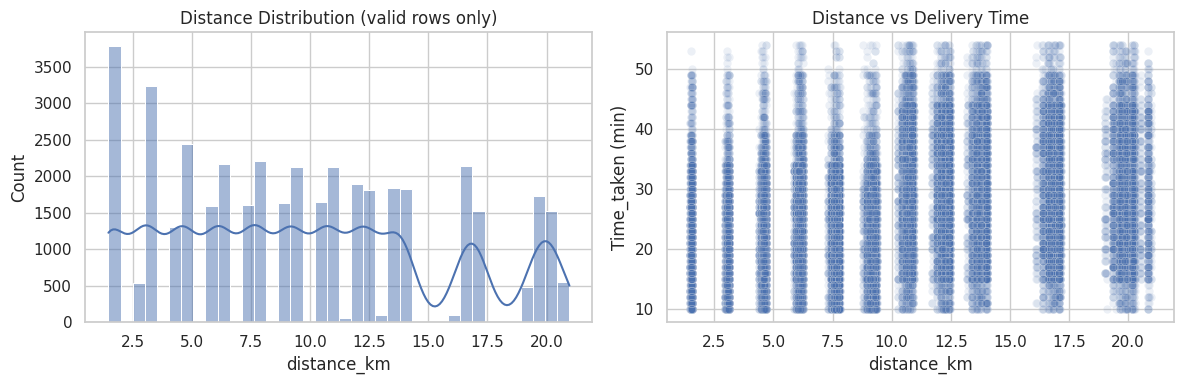

Max distance: 21.0 km
Rows with distance > 50 km: 0


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["distance_km"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distance Distribution (valid rows only)")
sns.scatterplot(x=df["distance_km"], y=df[target_col], alpha=0.1, ax=axes[1])
axes[1].set_title("Distance vs Delivery Time")
plt.tight_layout()
plt.show()

print(f"Max distance: {df['distance_km'].max():.1f} km")
print(f"Rows with distance > 50 km: {(df['distance_km'] > 50).sum()}")

## Remaining Invalid-Value Checks

Age, ratings, vehicle condition, multiple deliveries, and target sanity checks.

In [25]:
print(df["Delivery_person_Age"].describe())
print(f"\nAges outside plausible working range (18-65): {((df['Delivery_person_Age'] < 18) | (df['Delivery_person_Age'] > 65)).sum()}")

count    43730.000000
mean        29.566911
std          5.815064
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

Ages outside plausible working range (18-65): 38


In [26]:
print(df["Delivery_person_Ratings"].describe())
print(f"\nRatings outside 0-5: {((df['Delivery_person_Ratings'] < 0) | (df['Delivery_person_Ratings'] > 5)).sum()}")

count    43676.000000
mean         4.633774
std          0.334744
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

Ratings outside 0-5: 53


In [27]:
print("Vehicle_condition unique values:", sorted(df["Vehicle_condition"].unique()))
print("multiple_deliveries unique values:", sorted(df["multiple_deliveries"].dropna().unique()))

Vehicle_condition unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
multiple_deliveries unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [28]:
print(f"Time_taken <= 0: {(df[target_col] <= 0).sum()}")
print(f"Time_taken extreme high (>90 min, arbitrary check threshold): {(df[target_col] > 90).sum()}")
df[target_col].sort_values(ascending=False).head(10)

Time_taken <= 0: 0
Time_taken extreme high (>90 min, arbitrary check threshold): 0


,Time_taken (min)
3094,54
3702,54
45034,54
38749,54
39364,54
38457,54
38583,54
7035,54
7881,54
12617,54


## Data Quality: Duplicates, Age, Ratings, Target Skew

In [29]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate IDs: {df.duplicated(subset=['ID']).sum()}")
print(f"Duplicate Delivery_person_ID + Order_Date + Time_Orderd combos: "
      f"{df.duplicated(subset=['Delivery_person_ID', 'Order_Date', 'Time_Orderd']).sum()}")

Exact duplicate rows: 0
Duplicate IDs: 0
Duplicate Delivery_person_ID + Order_Date + Time_Orderd combos: 154


In [30]:
print(df[target_col].describe())
print(f"\nSkewness: {df[target_col].skew():.3f}")
print(f"Mean: {df[target_col].mean():.2f}, Median: {df[target_col].median():.2f}")

count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

Skewness: 0.486
Mean: 26.29, Median: 26.00


In [31]:
young_age = df[df["Delivery_person_Age"] < 18]
print(f"Count: {len(young_age)}")
print(young_age["Delivery_person_Age"].value_counts().sort_index())
print(f"\nTarget mean for age<18 group: {young_age[target_col].mean():.2f}")
print(f"Target mean overall: {df[target_col].mean():.2f}")

Count: 38
Delivery_person_Age
15.0    38
Name: count, dtype: int64

Target mean for age<18 group: 26.00
Target mean overall: 26.29


In [32]:
print(f"Ratings > 5: {(df['Delivery_person_Ratings'] > 5).sum()}")
print(f"Ratings < 0: {(df['Delivery_person_Ratings'] < 0).sum()}")
df[df["Delivery_person_Ratings"] > 5]["Delivery_person_Ratings"].value_counts().sort_index()

Ratings > 5: 53
Ratings < 0: 0


,count
Delivery_person_Ratings,
6.0,53


## Finalize Data Quality Corrections

In [33]:
df.loc[df["Delivery_person_Ratings"] > 5, "Delivery_person_Ratings"] = np.nan
print(f"Ratings > 5 remaining: {(df['Delivery_person_Ratings'] > 5).sum()}")
print(f"Ratings missing now: {df['Delivery_person_Ratings'].isna().sum()}")

Ratings > 5 remaining: 0
Ratings missing now: 1961


## Cleaning Rules Documented So Far

- **Coordinates**: 431 sign-flipped rows corrected via `abs()`. 3,640 rows with (0,0) restaurant
  coordinates are unrecoverable — kept in the dataset, `distance_km` set to NaN, flagged via
  `coords_corrupted` (impute at pipeline stage, train-fold-only).
- **`Time_Orderd` / `Time_Order_picked`**: normalized 3 mixed formats (HH:MM, HH:MM:SS with
  rollover, Excel day-fraction strings) into `order_time_min` / `pickup_time_min` (minutes since
  midnight). No unparseable values found.
- **`Delivery_person_Age`**: min value 15 kept as-is — single repeated value, target behavior
  identical to overall population, looks like the real floor of the distribution rather than error.
- **`Delivery_person_Ratings`**: 53 rows with value 6.0 (invalid on a 0-5 scale) set to NaN —
  hard sentinel, not boundary noise, so imputing is more honest than clipping to 5.0.
- **Duplicates**: no exact duplicate rows. 154 same-courier/same-timestamp combos kept — plausible
  given `multiple_deliveries` exists as a real feature.
- **Missing values**: genuine, modest (0.5-4.2%), left as NaN for now — imputation happens inside
  the pipeline post-split to avoid leakage (Section 12 of the plan).

## Temporal Feature Construction

In [34]:
df["order_date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y")
df["order_datetime"] = df["order_date"] + pd.to_timedelta(df["order_time_min"], unit="m")

df["order_hour"] = df["order_datetime"].dt.hour
df["order_day_of_week"] = df["order_datetime"].dt.dayofweek  # 0=Monday
df["is_weekend"] = df["order_day_of_week"].isin([5, 6]).astype(int)
df["order_month"] = df["order_datetime"].dt.month

print(df["order_date"].min(), "to", df["order_date"].max())
df[["order_datetime", "order_hour", "order_day_of_week", "is_weekend"]].head()

2022-02-11 00:00:00 to 2022-04-06 00:00:00


,order_datetime,order_hour,order_day_of_week,is_weekend
0,2022-02-12 21:55:00,21.0,5.0,1
1,2022-02-13 14:55:00,14.0,6.0,1
2,2022-03-04 17:30:00,17.0,4.0,0
3,2022-02-13 09:20:00,9.0,6.0,1
4,2022-02-14 19:50:00,19.0,0.0,0


                 mean  count
order_hour                  
0.0         22.169767    430
8.0         19.580627   1817
9.0         19.543914   1947
10.0        19.457875   2184
11.0        27.165158   1768
12.0        26.826233    892
13.0        27.529755    857
14.0        27.543933    717
15.0        23.194731    873
16.0        22.932903    775
17.0        27.477559   4211
18.0        27.276178   4479
19.0        30.862158   5042
20.0        31.178528   4089
21.0        31.090928   4685
22.0        23.145458   4998
23.0        22.435314   4089


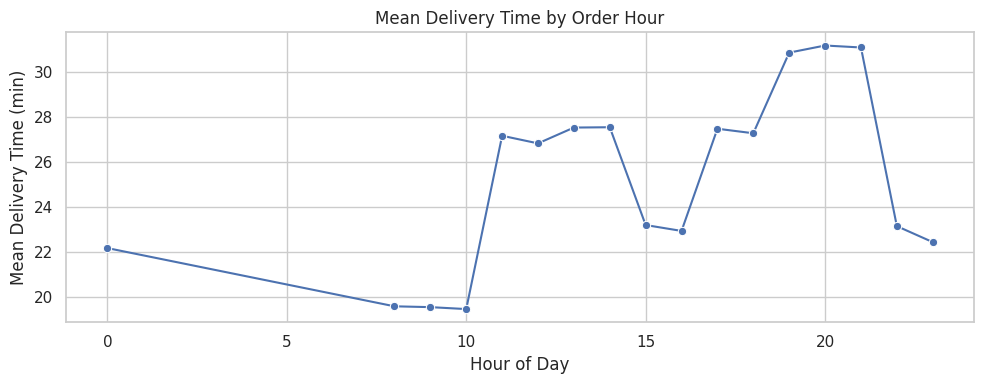

In [35]:
hourly_mean = df.groupby("order_hour")[target_col].agg(["mean", "count"]).sort_index()
print(hourly_mean)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=hourly_mean.index, y=hourly_mean["mean"], marker="o", ax=ax)
ax.set_title("Mean Delivery Time by Order Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Delivery Time (min)")
plt.tight_layout()
plt.show()

## Data-Justified Time-of-Day Buckets

In [36]:
present_hours = sorted(df["order_hour"].dropna().unique())
print(f"Hours present in data: {present_hours}")
print(f"Missing hours: {[h for h in range(24) if h not in present_hours]}")

Hours present in data: [np.float64(0.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0)]
Missing hours: [1, 2, 3, 4, 5, 6, 7]


In [37]:
def bucket_hour(hour):
    if pd.isna(hour):
        return np.nan
    hour = int(hour)
    if hour in [8, 9, 10]:
        return "morning_lull"
    elif hour in [11, 12, 13, 14]:
        return "lunch_peak"
    elif hour in [15, 16]:
        return "afternoon_lull"
    elif hour in [17, 18]:
        return "evening"
    elif hour in [19, 20, 21]:
        return "dinner_peak"
    else:  # 22, 23, 0
        return "late_night"

df["order_period"] = df["order_hour"].apply(bucket_hour)
df["is_peak_hour"] = df["order_period"].isin(["lunch_peak", "dinner_peak"]).astype(int)

df.groupby("order_period")[target_col].agg(["mean", "count"]).sort_values("mean")

,mean,count
order_period,,
morning_lull,19.523537,5948
late_night,22.796259,9517
afternoon_lull,23.071602,1648
lunch_peak,27.231696,4234
evening,27.373763,8690
dinner_peak,31.033367,13816


## Categorical Relationships with Delivery Time

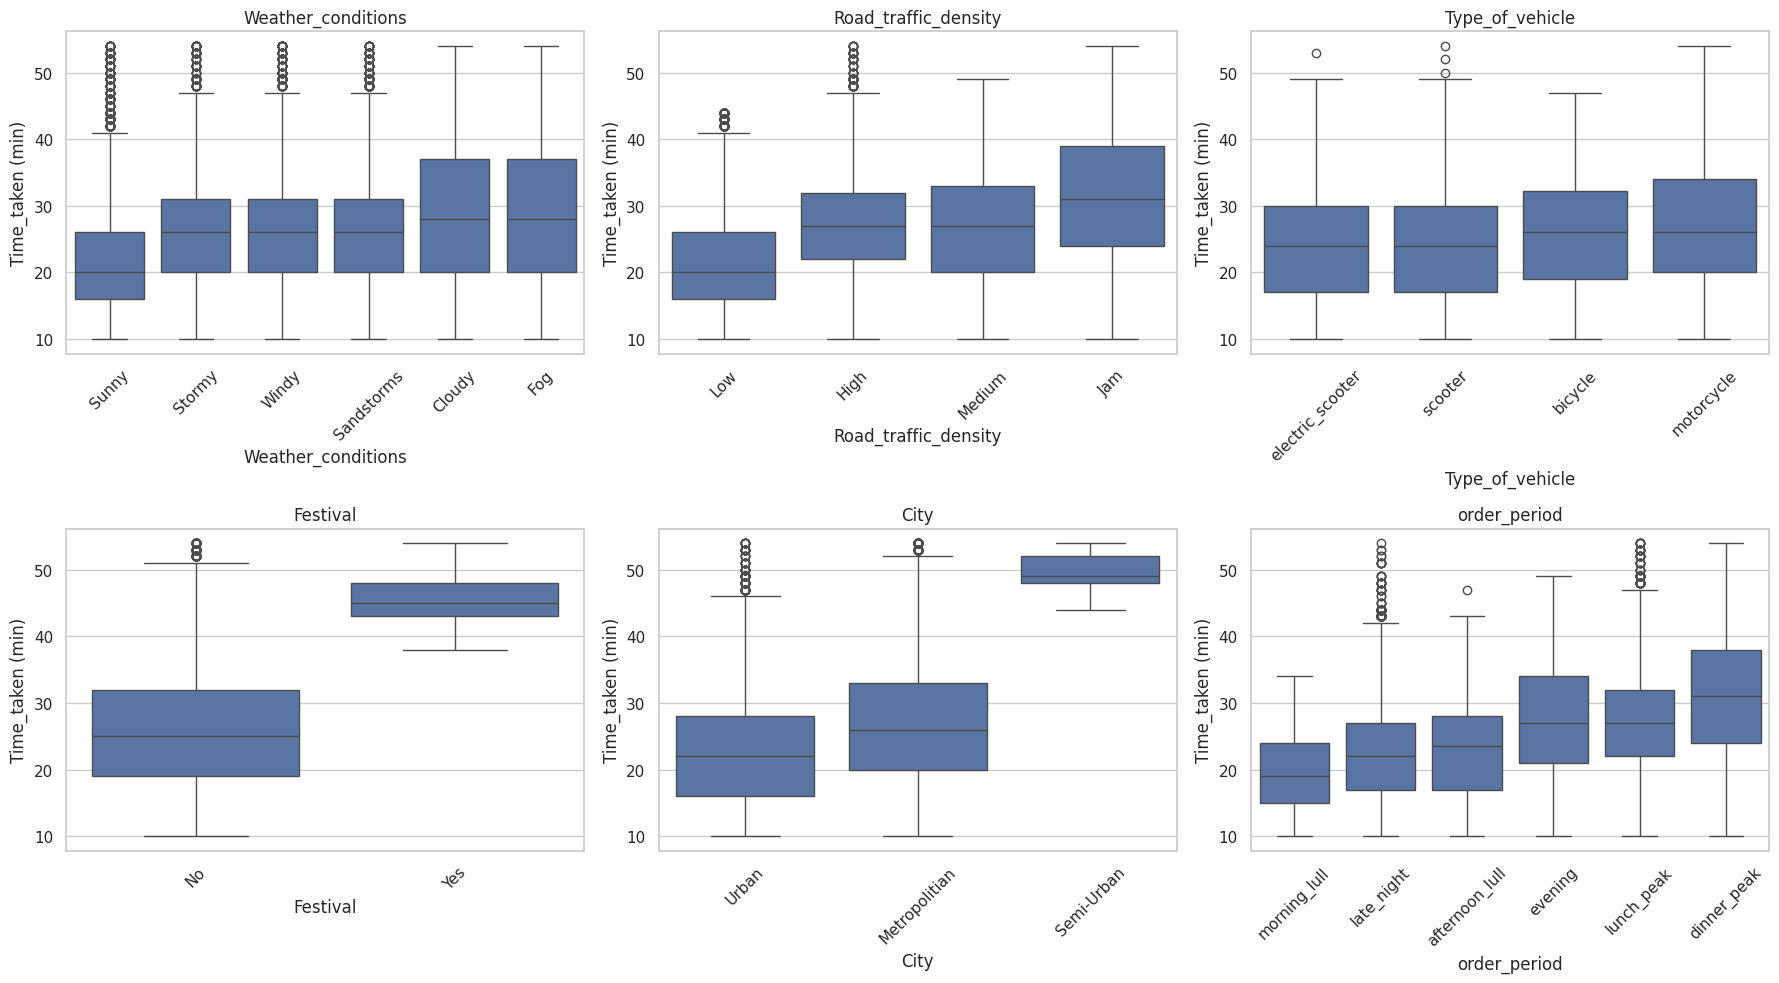

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_feature_cols = ["Weather_conditions", "Road_traffic_density", "Type_of_vehicle",
                     "Festival", "City", "order_period"]

for ax, col in zip(axes.flat, cat_feature_cols):
    order = df.groupby(col)[target_col].median().sort_values().index
    sns.boxplot(data=df, x=col, y=target_col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [39]:
for col in cat_feature_cols:
    print(f"--- {col} ---")
    print(df.groupby(col)[target_col].agg(["mean", "median", "count"]).sort_values("mean"))
    print()

--- Weather_conditions ---
                         mean  median  count
Weather_conditions                          
Sunny               21.856770    20.0   7282
Stormy              25.868803    26.0   7584
Sandstorms          25.875500    26.0   7494
Windy               26.118836    26.0   7422
Fog                 28.914674    28.0   7653
Cloudy              28.917164    28.0   7533

--- Road_traffic_density ---
                           mean  median  count
Road_traffic_density                          
Low                   21.266671    20.0  15476
Medium                26.699680    27.0  10945
High                  27.240109    27.0   4423
Jam                   31.176038    31.0  14139

--- Type_of_vehicle ---
                       mean  median  count
Type_of_vehicle                           
electric_scooter  24.470110    24.0   3814
scooter           24.478819    24.0  15273
bicycle           26.426471    26.0     68
motorcycle        27.605774    26.0  26429

--- Festival ---


## Feature Leakage Audit

**Prediction framing**: prediction happens at order placement. Any information that only becomes
known after the order is placed is excluded from the feature set.

In [40]:
available_at_prediction = [
    "Delivery_person_Age", "Delivery_person_Ratings",
    "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "distance_km", "coords_corrupted",
    "Weather_conditions", "Road_traffic_density",
    "Vehicle_condition", "Type_of_order", "Type_of_vehicle",
    "multiple_deliveries", "Festival", "City",
    "order_hour", "order_day_of_week", "is_weekend", "order_month",
    "order_period", "is_peak_hour",
]

leakage_excluded = [
    "Time_Order_picked", "pickup_time_min", "prep_time_min",  # only known after courier pickup
]

print("Available at prediction time:")
print(available_at_prediction)
print(f"\nExcluded as leakage ({len(leakage_excluded)} cols):")
print(leakage_excluded)

# Confirm none of the "available" columns leak by correlating suspiciously high with target
print("\nCorrelation of numeric 'available' features with target (leakage sanity check):")
numeric_available = [c for c in available_at_prediction if df[c].dtype in ["float64", "int64"]]
print(df[numeric_available + [target_col]].corr()[target_col].sort_values(ascending=False))

Available at prediction time:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'distance_km', 'coords_corrupted', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'order_hour', 'order_day_of_week', 'is_weekend', 'order_month', 'order_period', 'is_peak_hour']

Excluded as leakage (3 cols):
['Time_Order_picked', 'pickup_time_min', 'prep_time_min']

Correlation of numeric 'available' features with target (leakage sanity check):
Time_taken (min)               1.000000
multiple_deliveries            0.387042
is_peak_hour                   0.331972
distance_km                    0.320474
Delivery_person_Age            0.299523
order_hour                     0.185051
Delivery_location_latitude     0.014234
Restaurant_latitude            0.012630
Delivery_location_longitude    0.007590
Rest

## Numerical Relationships

Correlation and binned means for distance, courier age/ratings, vehicle condition vs. target.

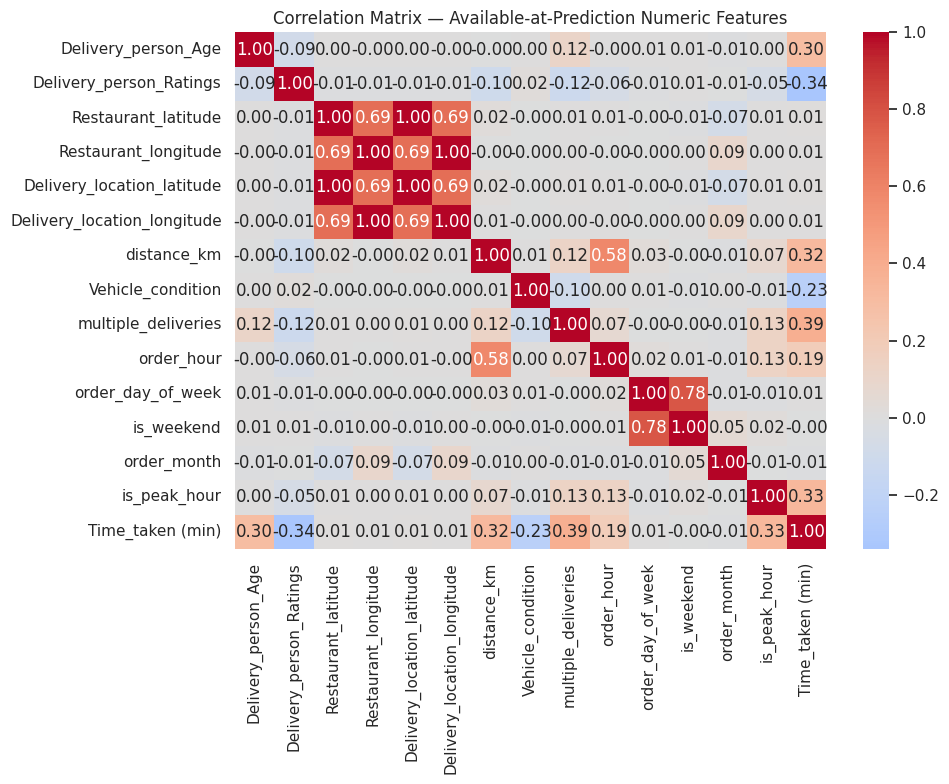

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_available + [target_col]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Available-at-Prediction Numeric Features")
plt.tight_layout()
plt.show()

                      mean  count
distance_bucket                  
(0, 2]           21.458774   3784
(2, 5]           22.553885   7516
(5, 10]          24.387351  11305
(10, 15]         29.834942  11293
(15, 21]         29.858563   8046


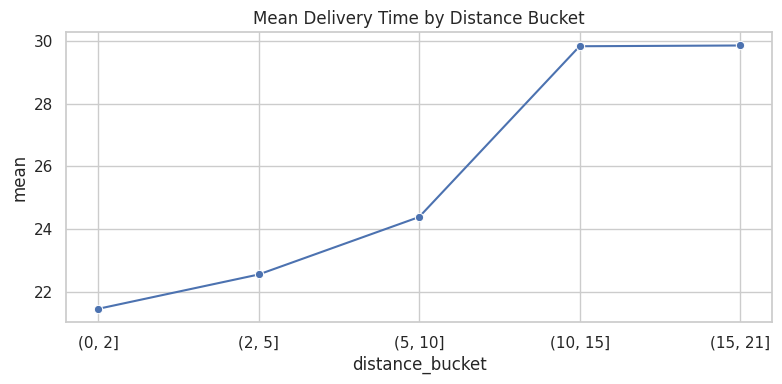

In [42]:
df["distance_bucket"] = pd.cut(df["distance_km"], bins=[0, 2, 5, 10, 15, 21])
binned = df.groupby("distance_bucket", observed=True)[target_col].agg(["mean", "count"])
print(binned)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=binned.index.astype(str), y=binned["mean"], marker="o", ax=ax)
ax.set_title("Mean Delivery Time by Distance Bucket")
plt.tight_layout()
plt.show()

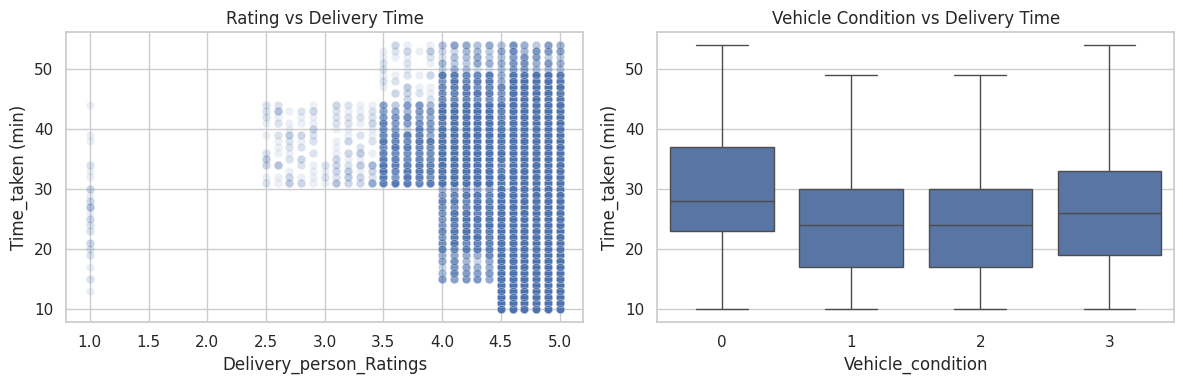

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df["Delivery_person_Ratings"], y=df[target_col], alpha=0.1, ax=axes[0])
axes[0].set_title("Rating vs Delivery Time")

sns.boxplot(x=df["Vehicle_condition"], y=df[target_col], ax=axes[1])
axes[1].set_title("Vehicle Condition vs Delivery Time")
plt.tight_layout()
plt.show()

## Type_of_order vs Delivery Time (missed in the categorical sweep)

                    mean  median  count
Type_of_order                          
Drinks         26.187969    25.0  11321
Buffet         26.283320    26.0  11277
Snack          26.285603    26.0  11530
Meal           26.417598    26.0  11456


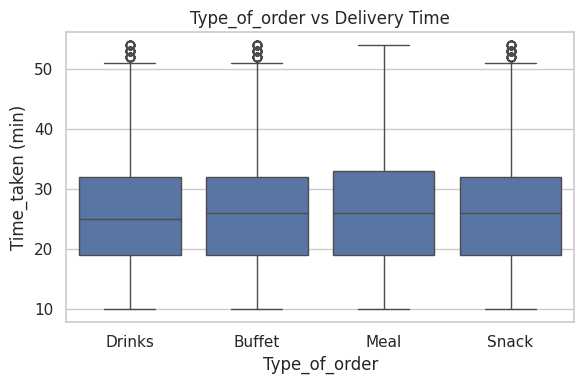

In [44]:
print(df.groupby("Type_of_order")[target_col].agg(["mean", "median", "count"]).sort_values("mean"))

fig, ax = plt.subplots(figsize=(6, 4))
order = df.groupby("Type_of_order")[target_col].median().sort_values().index
sns.boxplot(data=df, x="Type_of_order", y=target_col, order=order, ax=ax)
ax.set_title("Type_of_order vs Delivery Time")
plt.tight_layout()
plt.show()

## Missingness Pattern Check — City and multiple_deliveries

multiple_deliveries is our strongest numeric correlate with the target (0.39), so if its
missingness isn't random, that materially affects how we should impute it. Same logic for City.

In [45]:
df["City_missing"] = df["City"].isna()

print("City missingness by Road_traffic_density:")
print(df.groupby("Road_traffic_density")["City_missing"].mean().sort_values(ascending=False))

print("\nCity missingness by order_period:")
print(df.groupby("order_period")["City_missing"].mean().sort_values(ascending=False))

print(f"\nTarget mean when City missing: {df[df['City_missing']][target_col].mean():.2f}")
print(f"Target mean when City present: {df[~df['City_missing']][target_col].mean():.2f}")

City missingness by Road_traffic_density:
Road_traffic_density
Low       0.034376
Medium    0.023572
High      0.022157
Jam       0.020581
Name: City_missing, dtype: float64

City missingness by order_period:
order_period
late_night        0.035515
morning_lull      0.031607
afternoon_lull    0.025485
evening           0.023475
lunch_peak        0.022437
dinner_peak       0.020049
Name: City_missing, dtype: float64

Target mean when City missing: 22.06
Target mean when City present: 26.41


In [46]:
df["multiple_deliveries_missing"] = df["multiple_deliveries"].isna()

print("multiple_deliveries missingness by Road_traffic_density:")
print(df.groupby("Road_traffic_density")["multiple_deliveries_missing"].mean().sort_values(ascending=False))

print("\nmultiple_deliveries missingness by Type_of_order:")
print(df.groupby("Type_of_order")["multiple_deliveries_missing"].mean().sort_values(ascending=False))

print(f"\nTarget mean when multiple_deliveries missing: {df[df['multiple_deliveries_missing']][target_col].mean():.2f}")
print(f"Target mean when multiple_deliveries present: {df[~df['multiple_deliveries_missing']][target_col].mean():.2f}")

multiple_deliveries missingness by Road_traffic_density:
Road_traffic_density
Low       0.026751
High      0.020122
Medium    0.020101
Jam       0.018318
Name: multiple_deliveries_missing, dtype: float64

multiple_deliveries missingness by Type_of_order:
Type_of_order
Snack     0.022984
Buffet    0.021992
Meal      0.021386
Drinks    0.020758
Name: multiple_deliveries_missing, dtype: float64

Target mean when multiple_deliveries missing: 22.77
Target mean when multiple_deliveries present: 26.37


In [47]:
df = df.drop(columns=["Time_Orderd_missing", "City_missing", "multiple_deliveries_missing"])

## Data Dictionary

Built from actual inspection of this dataset (Section 2 of the plan), not assumed from the
description.

| Column | Meaning | Type | Role | Potential Issues |
|---|---|---|---|---|
| `ID` | Order identifier | object | Identifier | none |
| `Delivery_person_ID` | Courier identifier | object | Identifier | none |
| `Delivery_person_Age` | Courier age (years) | float64 | Feature | 4.07% missing; min=15 kept as real floor of distribution, not an error |
| `Delivery_person_Ratings` | Courier rating (0-5 scale) | float64 | Feature | 53 rows had invalid 6.0 → set NaN; now 4.3% missing total |
| `Restaurant_latitude/longitude` | Restaurant coordinates | float64 | Feature (source for `distance_km`) | 431 sign-flipped rows fixed via `abs()`; 3,640 rows unsalvageable at (0,0), flagged via `coords_corrupted` |
| `Delivery_location_latitude/longitude` | Delivery coordinates | float64 | Feature (source for `distance_km`) | same as above |
| `Order_Date` | Order date, string | object | Source only | used to build `order_date`/`order_datetime`, not used directly |
| `Time_Orderd` | Order time, string, 3 mixed formats | object | Source only | 3.80% missing, confirmed random (not structural); used to build `order_time_min` |
| `Time_Order_picked` | Courier pickup time, string | object | **Excluded — leakage** | only known after courier pickup, post-order-placement |
| `Weather_conditions` | Weather at order time | object | Feature | 1.35% missing |
| `Road_traffic_density` | Traffic level | object | Feature | 1.32% missing; monotonic relationship with target (Low→Jam) |
| `Vehicle_condition` | Vehicle condition, ordinal 0-3 | int64 | Feature | no missing |
| `Type_of_order` | Snack/Meal/Drinks/Buffet | object | Feature | no missing; weak separation vs. target |
| `Type_of_vehicle` | motorcycle/scooter/electric_scooter/bicycle | object | Feature | no missing; `bicycle` only 68 rows — small-sample caution |
| `multiple_deliveries` | Count of concurrent deliveries, 0-3 | float64 | Feature | 2.18% missing; strongest numeric correlate with target (r=0.39) |
| `Festival` | Festival day flag | object | Feature | 0.50% missing; largest categorical effect seen (+20 min on Yes) |
| `City` | Urban/Metropolitian/Semi-Urban | object | Feature | 2.63% missing; `Semi-Urban` only 164 rows — small-sample caution |
| `Time_taken (min)` | Total delivery time | int64 | **Target** | no missing, no invalid values; skew 0.49 (mild right skew) |
| `order_time_min` | Order time as minutes since midnight | float64 | Feature | derived from `Time_Orderd`; inherits its 3.80% missing |
| `pickup_time_min` | Pickup time as minutes since midnight | float64 | **Excluded — leakage** | derived from `Time_Order_picked` |
| `prep_time_min` | pickup − order time | float64 | **Excluded — leakage** | quantized to 5/10/15 — looks synthetic, not raw operational data |
| `coords_corrupted` | Flag for unsalvageable (0,0) coordinates | bool | Feature | 3,640 rows (8.0%) |
| `distance_km` | Haversine distance, restaurant→delivery | float64 | Feature | NaN for `coords_corrupted` rows; otherwise clean, 1.47-21.0 km range |
| `distance_bucket` | Binned `distance_km` | category | EDA/error-segmentation only, not a model feature | — |
| `order_date` / `order_datetime` | Parsed date / full timestamp | datetime | Intermediate only | used to build calendar features and temporal split |
| `order_hour` | Hour of order | float64 | Feature (source for `order_period`) | hours 1-7 absent from data entirely (operational gap, not missing data) |
| `order_day_of_week` | 0=Monday..6=Sunday | int64 | Feature | — |
| `is_weekend` | Sat/Sun flag | int64 | Feature | — |
| `order_month` | Order month | int64 | Feature | data spans Feb 11 - Apr 6, 2022 only — narrow window, limited seasonal signal |
| `order_period` | morning_lull/lunch_peak/afternoon_lull/evening/dinner_peak/late_night | object | Feature | thresholds empirically derived from hourly mean target, not arbitrary |
| `is_peak_hour` | lunch_peak or dinner_peak flag | int64 | Feature | derived from `order_period` |
| `split_random` | train/val/test, random 70/15/15 | object | Split indicator, not a feature | — |
| `split_temporal` | train/val/test, time-ordered | object | Split indicator, not a feature | — |

## Final Feature Set Assembly

In [48]:
# ID and Delivery_person_ID are identifiers, not predictive features on their own —
# excluded from the modeling feature set but kept in the saved dataframe for traceability
id_cols = ["ID", "Delivery_person_ID"]

feature_cols = available_at_prediction  # defined earlier in leakage audit
target_col = "Time_taken (min)"

print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)

Final feature count: 22
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'distance_km', 'coords_corrupted', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'order_hour', 'order_day_of_week', 'is_weekend', 'order_month', 'order_period', 'is_peak_hour']


## Train / Validation / Test Split

Random 70/15/15 split for main model development, plus a secondary time-based split
(earlier orders -> train, later orders -> val/test) to test generalization to future orders.

In [49]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=RANDOM_SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_SEED)

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df):.1%})")

df["split_random"] = "train"
df.loc[val_df.index, "split_random"] = "val"
df.loc[test_df.index, "split_random"] = "test"

Train: 31908 (70.0%)
Val:   6838 (15.0%)
Test:  6838 (15.0%)


In [50]:
df_sorted = df.sort_values("order_datetime")
n = len(df_sorted)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df["split_temporal"] = "train"
df.loc[df_sorted.index[train_end:val_end], "split_temporal"] = "val"
df.loc[df_sorted.index[val_end:], "split_temporal"] = "test"

print(df.groupby("split_temporal")["order_datetime"].agg(["min", "max", "count"]))

                               min                 max  count
split_temporal                                               
test           2022-04-01 22:55:00 2022-04-07 00:00:00   5107
train          2022-02-11 08:10:00 2022-03-26 11:25:00  31908
val            2022-03-26 11:25:00 2022-04-01 22:55:00   6838


## Save Prepared Data to Drive

In [51]:
import os
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

# Convert problematic column to string before saving
df["distance_bucket"] = df["distance_bucket"].astype(str)

df.to_parquet(f"{DRIVE_OUTPUT_DIR}/prepared_data.parquet", index=True)

import json
metadata = {
    "target_col": target_col,
    "feature_cols": feature_cols,
    "id_cols": id_cols,
    "leakage_excluded_cols": leakage_excluded,
    "random_seed": RANDOM_SEED,
}
with open(f"{DRIVE_OUTPUT_DIR}/feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {DRIVE_OUTPUT_DIR}")
print(f"Final shape: {df.shape}")

Saved to /content/drive/MyDrive/zomato-delivery-time-prediction
Final shape: (45584, 36)


## Cleaning Rules — Addendum (Missingness Patterns)

- **`Type_of_order`**: no meaningful relationship with target (26.19-26.42 across all categories) —
  confirmed weak predictor, kept as feature but expect low importance.
- **`City` missingness is informative, not random**: target mean 22.06 (missing) vs 26.41 (present).
  Pipeline decision: impute with explicit "Unknown" category, not mode — preserves the signal.
- **`multiple_deliveries` missingness is informative, not random**: target mean 22.77 (missing) vs
  26.37 (present). Pipeline decision: `SimpleImputer(add_indicator=True)` — imputes the value AND
  auto-generates a missingness flag feature, rather than hand-building one.